# Sleep and Health Metric Dataset

I chose an open access sleep and health metric dataset for exploration in sleep disorders and how an individual's occupation, health, and sleep quality may have an association with a lack of a disorder, insomnia, or sleep apnea. Sleep impacts our lives just as much as our lives or choices we make in our health impact our sleep. Exploring the collected health metrics of occupation, sleep duration (hours), quality of sleep (1-10), physical activity (minutes/day), stress level (1-10), BMI category (underweight, normal, overweight), blood pressure (systolic/diastolic), heart rate (bpm), sleep disorder (none, insomnia, sleep apnea) may provide valuable insights into patterns related to sleep outcomes. This dashboard explores relationships among sleep disorder status, sleep duration, sleep quality, stress level, BMI category, health metrics, and occupation.

The dashboard is organized to start with individual sleep outcomes and then expand to broader health and lifestyle metrics. The bubble scatter plot introduces the relationship between sleep duration, sleep quality, stress level, and sleep disorder status. The interactive box plot then allows users to explore whether other health metrics show similar differences across sleep disorder groups. The stacked bar chart examines BMI category as a categorical health factor and shows how sleep disorder status is distributed within each BMI group. Lastly, the heat map provides broader lifestyle context by showing how sleep disorder status varies across occupations.

Lastly, you can manipulate the population in the final dashboard to explore how age and gender may change the distribution of data among sleep disorders and sleep and health metrics.

Together, these four visualizations explore sleep health from multiple perspectives: direct sleep outcomes, related health metrics, BMI category, and occupation. This structure helps users move from individual-level sleep patterns to broader health and lifestyle trends.

# Visualization Library

Visualization library chosen for this assignment is Plotly Python Graphing Library (plotly.com/python/). Plotly is open source and can be displayed with Jupitor Notebooks and also be used in other coding software such as R, Javascript, and Julia. Plotly has many different graphing options (only scatterplots, boxplots, heat maps, and bar graphs are used in this example) and has documentation for using Jupyter widgets. Additionally, I specifically used ipywidgets to create an interactive dashboard exploration tool and Google Colab to host the notebook to run without installation and configuration. 

The plotly website is easy to understand with many examples and easy to search documentation. With it being open source there is a thriving community forum (community.plotly.com) and additional source code on GitHub (github.com/plotly/plotly.py) for additional community contribution and support. 

Plotly has both declarative, using Plotly Express, and procedural, using Graph Objects (used in this example), coding for how you would like to create your plots.

I chose Plotly due to its easy to understand community and examples and similarity to other visualization libraries used in the past. I appreciated its professional plots and ability to customize as needed as well as the choice between Plotly Express or Graph Objects. I used graph objects because of its detailed control over each trace and layout of plots.

## Installing Plotly (reference: plotly.com/python/getting-started/) on your personal computer

### Installing using pip:

$ pip install plotly

### Installing using conda:

$ conda install -c conda-forge plotly

## How to Run This Dashboard in Google Collab

1. Log in and open this Notebook in Google Colab: https://drive.google.com/file/d/1bo--lGe97v0_g6ECILHS5fBIcjfmCz8s/view?usp=sharing
2. Select "Run all" in the top banner or "Runtime" tab and then "Run all"
3. Wait for all cells to finish running
4. Scroll downt to the bottom to explore the final dashboard where you can interact with the population (gender and age) and health metrics in the box plot

# Import Libraries

The following code imports libraries needed for data cleaning, manipulation, and visualizations in this notebook.

In [49]:
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact
import plotly.graph_objects as go
import plotly.io as pio

#These are added for google colab to display the plots consistently
#from google.colab import output
#output.enable_custom_widget_manager()

#pio.renderers.default = "colab"

# Downloading and Cleanning Data

Sleep and health metrics data that was used in the projects was generated and published on kaggle (https://www.kaggle.com/) an open platform for researchers to share open datasets and create machine learning projects for exploring. The dataset I used the Sleep Health and Lifestyle Dataset found here https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset/data.

## Instructions for downloading and saving the dataset if running on your own computer

1. In the top right of the webpage for the Sleep Health and Lifestyle Dataset, click "Download"
2. From the dropdown, select "Download dataset as zip (3kb)"
3. Save the folder zip to your computer
4. Extract the Sleep_health_and_lifestyle_dataset csv file
5. Save the file to your directory

## Dataset Cleaning

In [2]:
#Read in the csv file using pd.read_csv and the file name it was saved under
url = "https://raw.githubusercontent.com/klorang/sleep-health-dashboard/main/Sleep_health_and_lifestyle_dataset.csv"
sleep_df = pd.read_csv(url)
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
#Inspect the unique values in each column to help identify any inconsistencies such as labels or missing values
for col in sleep_df.columns:
    print(f"{col}: {sleep_df[col].unique()}")

Person ID: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244

In [4]:
#It seems that there are a couple columns that need to be cleaned up. 

#Occupation has repeats of occupations that can be simplified and combined (Software engineer/Engineer & Sales Representative/salesperson)
sleep_df["Occupation"] = [x.replace("Software Engineer","Engineer") for x in sleep_df["Occupation"]]
sleep_df["Occupation"] = [x.replace("Sales Representative","Salesperson") for x in sleep_df["Occupation"]]

#BMI Category has two values for normal/normal weight
sleep_df["BMI Category"] = [x.replace("Normal Weight","Normal") for x in sleep_df["BMI Category"]]

#Split Blood Pressure into systolic and diastolic values for numeric analysis
sleep_df[["Systolic","Diastolic"]] = sleep_df["Blood Pressure"].str.split("/", expand=True)
sleep_df["Systolic"] = pd.to_numeric(sleep_df["Systolic"])
sleep_df["Diastolic"] = pd.to_numeric(sleep_df["Diastolic"])

#Sleep Disorders should have None instead of nan
sleep_df.fillna('None', inplace=True)

#Created a list of all disorders to use later when plotting
sleep_disorders = list(sleep_df["Sleep Disorder"].unique())

In [5]:
#Now lets check to make sure the raw dataframe looks correct now
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Salesperson,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Salesperson,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


# Plotting the Data

## Bubble Scatter Plot

I first wanted to explore if people with different sleep disorders display different patterns in sleep duration and sleep quality. Additionally, a bubble marker was used to see if stress levels may indicate poorer sleep outcomes as well as sleep disorder status.

Key features of the scatter plot:
- yaxis = adjusted in layout to indicate all potential values for sleep quality (1-10)
- Marker: adjusts the markers on the plot to be bubbles with larger markers indicating higher levels of reported stress and smaller indicating less.
- Color: coded for sleep disorder

From the plot suggests poorer sleep quality and shorter sleep duration appear more among reported sleep disorder participants. Additionally, higher stress levels (bigger markers) are more prevalent with poorer sleep factors. Insomnia and sleep apnea individuals are present in poorer sleep areas (shorter sleep duration and lower sleep quality).

In [6]:
#Create the figure
sleep_fig = go.Figure()

#Iterate over the disorder list (created earlier) and plot each participant
for disorder in sleep_disorders:
    sleep_fig.add_trace(go.Scatter(
        x=sleep_df["Sleep Duration"][sleep_df["Sleep Disorder"] == disorder], 
        y=sleep_df["Quality of Sleep"][sleep_df["Sleep Disorder"] == disorder], 
        name=disorder,
        mode="markers",
        marker=dict(size=sleep_df["Stress Level"][sleep_df["Sleep Disorder"] == disorder]*2,opacity=0.75)))

#Update and personalize the scatter plot
sleep_fig.update_layout(title="Sleep Duration vs Sleep Quality by Sleep Disorder<br><sup>Marker size respresents reported stress level",
                    xaxis_title="Sleep Duration (Hrs)",
                    yaxis_title="Sleep Quality",
                    legend_title="Sleep Disorders",
                    yaxis_range=[1,10])

sleep_fig.show()

In [36]:
#Next we will make our plot into a function and ready it to be used in our main dashboard at the end

def scatter_plot(df):

    sleep_fig = go.Figure()
        
    for disorder in sleep_disorders:
        sleep_fig.add_trace(go.Scatter(
            x=df["Sleep Duration"][df["Sleep Disorder"] == disorder], 
            y=df["Quality of Sleep"][df["Sleep Disorder"] == disorder], 
            name=disorder,
            mode="markers",
            marker=dict(size=df["Stress Level"][df["Sleep Disorder"] == disorder]*2,opacity=0.75)))
       
    sleep_fig.update_layout(title="Sleep Duration vs Sleep Quality by Sleep Disorder<br><sup>Marker size respresents reported stress level",
                        xaxis_title="Sleep Duration (Hrs)",
                        yaxis_title="Sleep Quality",
                        legend_title="Sleep Disorders",
                        yaxis_range=[1,10],
                        height=300, margin=dict(l=40, r=30, t=50, b=40))
    
    return sleep_fig

## Interactive Box Plot

We can dive deeper into additional health metrics and how they maybe associated with sleep disorders using interactive box plots. The interactive box plots will be created using ipywidget module which was imported in the earlier code box with plotly and pandas. We will be able to interact with the graph using a dropdown to select which health metric we would like to observe by sleep disorder. This will help us get a better understanding of the differences in reported health metrics and how they may be associated with sleep disorders reported.

Key features of the interactive box plot:
- Health Metrics: physical activity level, stress level, systolic, diastolic, heart rate, and daily steps were used to observe differences between disorders (others could be used as well by adding them to the health_metric list)
- Colors: sleep disorder identification color is kept consistent from the scatter plot
- Dropdown: use the dropdown to select/change which health metric you would like to observe
- Markers: markers are added next to the plot and jittered for a more transparent distribution
- Box plot: shows the distribution, median, spread, and potential outliers for the health metric

Each health metric comparison displays how health and lifestyle metrics may differ across sleep disorder groups. For example, some health metrics, such as stress level or blood pressure, may show clearer differences between groups while others, such as daily steps, may be less consistent or weaker between groups.

In [8]:
#Identify health metrics you would like to use from the dataset
health_metrics = ["Physical Activity Level", "Stress Level", "Systolic", "Diastolic", "Heart Rate", "Daily Steps"]

#Create the interactive dropdown box using interact from ipywidgets
@interact(col_name=
             widgets.Dropdown(
                 options=health_metrics,
                 value=health_metrics[0],
                 description="Health Metrics"))

#Create the box plot in combination with interact
def box_plot(col_name):
    #Create the figure
    health_metrics_fig = go.Figure()
    
    #Just like the scatter plot, iterate over the disorder list and plot each box plot
    for disorder in sleep_disorders:
        health_metrics_fig.add_trace(go.Box(y = sleep_df[col_name][sleep_df["Sleep Disorder"] == disorder], name=disorder, boxpoints="all", jitter=0.1))

    #Update and personalize the plot based on health metric selected
    health_metrics_fig.update_layout(title= f"Distribution of {col_name} by Sleep Disorder",
                       xaxis_title="Sleep Disorder",
                       yaxis_title=col_name,
                       showlegend=False)

    health_metrics_fig.show()

interactive(children=(Dropdown(description='Health Metrics', options=('Physical Activity Level', 'Stress Level…

In [35]:
#We will just need to edit the function slightly to be used later with the interact decorator for our final dashboard

def box_plot(df, col_name):
    health_metrics_fig = go.Figure()
    
    for disorder in sleep_disorders:
        health_metrics_fig.add_trace(go.Box(y = df[col_name][df["Sleep Disorder"] == disorder], name=disorder, boxpoints="all", jitter=0.1))

    health_metrics_fig.update_layout(title= f"Distribution of {col_name} by Sleep Disorder",
                       xaxis_title="Sleep Disorder",
                       yaxis_title=col_name,
                       showlegend=False,
                       height=300, margin=dict(l=40, r=30, t=50, b=40))

    return health_metrics_fig

## Stacked Bar Chart

Another health metric that may be beneficial to observe is BMI category and how it may be related to sleep disorders. Additional because both variables are categorical, it is easiest to compare using percentage of participants in each sleep disorder group within each BMI category.

Key features of the stacked bar chart:
- Colors: sleep disorder identification color is kept consistent from earlier plots
- Percent: totals 100% to allow for comparison across BMI categories
- Stacked: the bars are stacked for each category for an easier analysis of the sleep disorder percentage

The chart suggests that the normal BMI category is mostly respresented by individuals with no sleep disorder. In contrast, overweight and obese categories show higher percentages of sleep apnea and insomania. This does not prove BMI causes sleep disorders, but suggests it may be associated with sleep disorder status.

In [10]:
#Group by BMI category and identify counts for each sleep disorder
bmi_sleep = pd.DataFrame(sleep_df.groupby('BMI Category')["Sleep Disorder"].value_counts()).reset_index().pivot(index="BMI Category", columns="Sleep Disorder", values="count")

#Calculate the percentage of individuals with each sleep disorder for each BMI category
bmi_sleep = round(bmi_sleep.div(bmi_sleep.sum(axis=1), axis=0)*100,2).fillna(0)
bmi_sleep

Sleep Disorder,Insomnia,None,Sleep Apnea
BMI Category,,,
Normal,4.17,92.59,3.24
Obese,40.00,0.00,60.00
Overweight,43.24,12.84,43.92


In [11]:
#Create the figure
bmi_fig = go.Figure()


#Just like the scatter plot, iterate over the disorder list and plot bar graph
for disorder in sleep_disorders:
    bmi_fig.add_trace(go.Bar(
        x = bmi_sleep.index,
        y = bmi_sleep[disorder],
        name=disorder))

#Update and personalize the plot the graph as stacked
bmi_fig.update_layout(title="Percentage of Sleep Disorder Status by BMI Category",
       xaxis_title="BMI Category",
       yaxis_title="Precentage within BMI Category",
       barmode="stack",
       legend_title="Sleep Disorders")

bmi_fig.show()

In [34]:
#We know can make this into a function for the final dashboard including adding in the percent calculation

def bar_chart(df):

    bmi_sleep = pd.DataFrame(df.groupby('BMI Category')["Sleep Disorder"].value_counts()).reset_index().pivot(index="BMI Category", columns="Sleep Disorder", values="count")
    bmi_sleep = round(bmi_sleep.div(bmi_sleep.sum(axis=1), axis=0)*100,2).fillna(0)

    #Upon further testing I had to make sure all disorders were represented when you interact with the population age
    bmi_sleep = bmi_sleep.reindex(columns=sleep_disorders, fill_value=0)
    
    bmi_fig = go.Figure()

    for disorder in sleep_disorders:
        bmi_fig.add_trace(go.Bar(
            x = bmi_sleep.index,
            y = bmi_sleep[disorder],
            name=disorder))
    
    bmi_fig.update_layout(title="Percentage of Sleep Disorder Status by BMI Category",
           xaxis_title="BMI Category",
           yaxis_title="Precentage within BMI Category",
           barmode="stack",
           legend_title="Sleep Disorders",
           height=300, margin=dict(l=40, r=30, t=50, b=40))
    
    return bmi_fig

## Heat Map

Lastly, I used a heat map to explore how sleep disorders are distributed differently across occupation. Like the stacked bar charts, additional data manipulation will be needed to isolate and create percentages for each occupation and how it is distributed for each sleep disorder.

Key features of the heat map:
- Percent: for better understanding and visualization if how occupations are distributed for each sleep disorder
- Color intensity: represents the percentage of participants within each occupation who reported a sleep disorder
- Percent: better understand comparisons for occupations

The heat map paints a picture of how some occupations have a higher percentage of reported sleep disorders than others. For example, nurses show a higher percentage of sleep apnea while managers and doctors have a higher percentage of no disorders. These patterns may reflect broader lifestyle, work schedule, or health-related factors, but additional analysis is needed.

In [13]:
#Group by Occupation and identify counts for each sleep disorder
occupation_disorder = pd.DataFrame(sleep_df.groupby('Occupation')["Sleep Disorder"].value_counts()).reset_index().pivot(index="Occupation", columns="Sleep Disorder", values="count").fillna(0)

#Calculate the percentage of individuals with each sleep disorder for each BMI category
occupation_disorder = round(occupation_disorder.div(occupation_disorder.sum(axis=1), axis=0)*100,2).fillna(0)
occupation_disorder

Sleep Disorder,Insomnia,None,Sleep Apnea
Occupation,,,
Accountant,18.92,81.08,0.00
Doctor,4.23,90.14,5.63
Engineer,8.96,89.55,1.49
Lawyer,4.26,89.36,6.38
Manager,0.00,100.00,0.00
Nurse,4.11,12.33,83.56
Salesperson,85.29,5.88,8.82
Scientist,0.00,50.00,50.00
Teacher,67.50,22.50,10.00


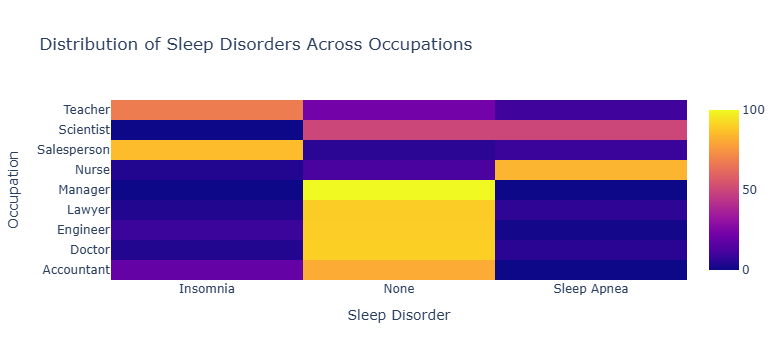

In [14]:
#Create the figure
occ_sleep_fig = go.Figure(data=go.Heatmap(
    z=occupation_disorder,
    x=occupation_disorder.columns,
    y=occupation_disorder.index))

#Update and personalize the plot
occ_sleep_fig.update_layout(title="Distribution of Sleep Disorders Across Occupations",
                           xaxis_title="Sleep Disorder",
                           yaxis_title="Occupation")

occ_sleep_fig.show()

In [37]:
#Create into a function like the rest adding in the percent calculation for the final dashboard
def heat_map(df):

    occupation_disorder = pd.DataFrame(df.groupby('Occupation')["Sleep Disorder"].value_counts()).reset_index().pivot(index="Occupation", columns="Sleep Disorder", values="count").fillna(0)
    occupation_disorder = round(occupation_disorder.div(occupation_disorder.sum(axis=1), axis=0)*100,2).fillna(0)

    #Upon further testing I had to make sure all disorders were represented when you interact with the population age
    occupation_disorder = occupation_disorder.reindex(columns=sleep_disorders, fill_value=0)
    
    occ_sleep_fig = go.Figure(data=go.Heatmap(
        z=occupation_disorder,
        x=occupation_disorder.columns,
        y=occupation_disorder.index))
    
    occ_sleep_fig.update_layout(title="Distribution of Sleep Disorders Across Occupations",
                               xaxis_title="Sleep Disorder",
                               yaxis_title="Occupation",
                               height=300, margin=dict(l=40, r=30, t=50, b=40))
    
    return occ_sleep_fig

# Creating the Final Dashboard

Lastly, I combine all four plots into an interactive dashboard using the functions created earlier. The dashboard allows users to filter the population by gender and age range to observe different associations across sleep and health metrics. These filters affect all of the graphs at once, rather than only one graph, as in the earlier box plot example.  

Instead of using the @interact decorator, as I did earlier in the box plot example, I used widgets.Output with HBox and VBox for more control over the dashboard layout. Initially, I used @interact, but it displayed the dashboard vertically with limited customization. Using Output containers allows each plot to be placed in its own area of the dashboard, while HBox and VBox arrange them into a 2x2 layout. This makes the dashboard easier to view and compare on one screen.

In [41]:
#First we will create the gender and age functions like we did for the box plot interactive variable
gender = widgets.Dropdown(
    options=["All","Male","Female"],
    value="All",
    description="Gender:")

age = widgets.IntRangeSlider(
    value=[sleep_df["Age"].min(), sleep_df["Age"].max()],
    min=sleep_df["Age"].min(),
    max=sleep_df["Age"].max(),
    step=1,
    description="Age:")

health_metric = widgets.Dropdown(
     options=health_metrics,
     value=health_metrics[0],
     description="Health Metrics")

In [42]:
#Next we will need to create a filter function to filter our data with only the gender and age requirements we would like to observe

def filter_df(gender, age_range):

    if gender != "All":
        filter_df = sleep_df[sleep_df["Gender"] == gender]
    else:
        filter_df = sleep_df

    filter_df = filter_df[(filter_df["Age"]>=age_range[0]) & (filter_df["Age"]<=age_range[1])]

    return filter_df

In [43]:
#Create plot widgets for each plot used so it can be arranged in a 2x2 dashboard

scatter = widgets.Output(layout=widgets.Layout(width="50%"))
box = widgets.Output(layout=widgets.Layout(width="50%"))
bar = widgets.Output(layout=widgets.Layout(width="50%"))
heat = widgets.Output(layout=widgets.Layout(width="50%"))

In [45]:
#Arrange the layout to be a 2x2 grid
controls = widgets.VBox([
    widgets.HTML("<h2>Sleep & Health Dashboard</h2>"),
    widgets.HBox([gender, age, health_metric])])

dashboard_grid = widgets.VBox([
    widgets.HBox([scatter, box]),
    widgets.HBox([bar, heat])])

In [48]:
#We need a function that can update the dashboard as age and gender are being manipulated (connect w
def update_dash(gender, age_range, health_metric):
    #Clear existing plots
    scatter.clear_output(wait=True)
    box.clear_output(wait=True)
    bar.clear_output(wait=True)
    heat.clear_output(wait=True)    
    
    #update the dateframe with the filters
    df = filter_df(gender, age_range)
    
    #Add in the Bubble Scatter Plot
    scatter_fig = scatter_plot(df)

    #Add in the box plot and update it with its own decorater
    box_fig = box_plot(df, health_metric)

    #Add in the stacked bar chart
    bar_fig = bar_chart(df)

    #Add in the heat map
    heatmap_fig = heat_map(df)

    #Display the dashboard with all plots together
    with scatter:
        display(scatter_fig)  
    with box:
        display(box_fig)
    with bar:
        display(bar_fig)
    with heat:
        display(heatmap_fig)

#connect widgets to dashboard functions
interactive_dashboard = widgets.interactive_output(update_dash,
    {"gender": gender, "age_range": age, "health_metric": health_metric})

display(controls)
display(dashboard_grid)
display(interactive_dashboard)

Output()